# 專案研究命題與核心動機 (Research Proposition & Motivation)

### 📌 研究背景與問題意識
近年來，**大麻（Marijuana）是否應該除罪化**在多個國家與地區都是相當熱門且具備高度爭議性的公共衛生話題。

在政論與公衛政策辯論中，反對除罪化陣營最常見的核心論述之一即為**「入門毒品假說」（Gateway Drug Theory）**——主張大麻的使用會破壞個體的心理防線或改變大腦成癮機制，進而**顯著增加未來涉入其他更嚴重之違禁品或非法管制藥品的人數與頻率**。

### 🎯 核心研究目的
本研究採取實證大數據分析戰略，旨在探討青少年階段大麻使用，與其他硬性毒品涉入嚴重度之間的共病結構。主要研究目的可拆解為以下兩大統計核心：

1. **多重成癮物質之互斥群體比較 (ANOVA)**：
   將青少年依據「香菸」、「酒精」與「大麻」的使用現況，精準切分為 **8 個互斥的物質涉入群體**（包含單一使用、多重物質併用、以及完全未涉入之對照組），透過 **ANOVA（變異數分析）** 檢定各群體在其他五種硬性管制藥品（古柯鹼、海洛因、吸入劑、甲基安非他命、搖頭丸）嚴重度評分上的均值是否存在顯著差異。
   
2. **多重物質協同成癮預測模型 (Linear Regression)**：
   在控制人口統計學變數的基礎上，評估現有的物質使用組合（抽菸、喝酒、吸食大麻），是否對其他違禁或管制藥品之涉入程度具備**顯著的複線性迴歸預測關係**，藉此驗證大麻是否具備獨立的通往效應，亦或與菸酒存在協同加乘的成癮衝擊。

# Project Proposition and Core Motivation

### 📌 Research Background and Problem Statement
In recent years, the **decriminalization and legalization of marijuana** have emerged as highly debated and controversial public health topics across multiple countries and regions worldwide.

Within political and public health policy debates, opponents frequently leverage the **"Gateway Drug Theory"** as a core argument. This theory posits that marijuana use compromises an individual's psychological defenses or alters neurological addiction mechanisms, thereby **significantly increasing the population and frequency of future involvement with other more severe illicit or controlled substances**.

### 🎯 Core Research Objectives
Adopting an empirical big data analysis strategy, this study aims to explore the comorbid structure between adolescent marijuana use and the severity of other hard drug involvement. The primary research objectives are operationalized into two statistical pillars:

1. **Comparison of Mutually Exclusive Substance Involvement Groups (ANOVA)**:
   Adolescents will be precisely stratified into **8 mutually exclusive substance involvement groups** based on their current consumption of cigarettes, alcohol, and marijuana (ranging from single-substance use and polysubstance use to a completely unexposed control group). **ANOVA (Analysis of Variance)** will be deployed to test whether the mean involvement severity scores for five other hard controlled substances (cocaine, heroin, inhalants, methamphetamine, and ecstasy) significantly differ across these distinct groups.
   
2. **Synergistic Polysubstance Addiction Prediction Model (Linear Regression)**:
   While controlling for demographic covariates, this study will evaluate whether current substance use combinations (tobacco, alcohol, and marijuana) exhibit a **significant multiple linear regression relationship** with the severity of involvement in other illicit or controlled substances. This will verify whether marijuana possesses an independent gateway effect or functions via a compounding, synergistic addictive impact alongside tobacco and alcohol.

In [20]:
import warnings
import logging
import os
import platform 

# 1. 忽略 Python 一般警告訊息 (如 Pandas 的 SettingWithCopyWarning)
warnings.filterwarnings('ignore')

# 2. 忽略特定模組的警告 
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. 顯示中文的設定
def set_ch_font():
    system = platform.system()
    if system == "Windows": 
        plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    elif system == "Darwin": 
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

set_ch_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'])

# 4. 設定 Pandas 顯示選項 (確保能完整檢視所有欄位)
pd.set_option('display.max_columns', None)

print("✅ 01_data-check 環境初始化完成")

✅ 01_data-check 環境初始化完成


In [21]:
# 1. 讀取 YRBSS 2007 原始資料集
df = pd.read_csv('../data/raw/YRBS_2007.csv')

# 2. 檢查資料集基本維度 (Shape)
print("📊 【資料集基本維度】")
print("-" * 30)
print(f"總樣本數 (Rows)：{df.shape[0]} 筆")
print(f"總欄位數 (Columns)：{df.shape[1]} 個")
print("-" * 30)

# 3. 數據初步外觀預覽 (不展開全表，僅看前 5 筆的結構)
print("\n👀 【資料集前 5 筆結構預覽】")
display(df.head())


📊 【資料集基本維度】
------------------------------
總樣本數 (Rows)：14041 筆
總欄位數 (Columns)：103 個
------------------------------

👀 【資料集前 5 筆結構預覽】


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,RidingWithADrinkingDriver,DrinkingAndDriving,WeaponCarrying,GunCarryingPast12Mos,WeaponCarryingAtSchool,SafetyConcernsAtSchool,WereThreatenedOrInjuredWithAWeaponOnSchoolProperty,StolenOrDamagedYourProperty,PhysicalFighting,InjuredIFight,PhysicalFightingAtSchool,BoyfriendGirlfriendPhysicallyHurt,ForcedSexualIntercourse,SadOrHopeless,ConsideredSuicide,MadeASuicidePlan,AttemptedSuicide,InjuriousSuicide,EverCigaretteUse,InitiationSmokingWholeCigarette,CurrentCigaretteUse,SmokedMoreThan10Cigarettes,HowObtainedCigarettes,SmokeOnSchoolProperty,EverSmokedDailyFor30Days,EverSmokingCessation,CurrentSmokelessTobaccoUse,CurrentSmokelessTobaccoOnSchoolProperty,CurrentCigarUse,EverAlcoholUse,InitiationOfAlcoholUse,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,SourceOfAlcohol,DrinkAlcoholOnSchoolProperty,EverMarijuaUse,InitiationOfMarijuaUse,CurrentMarijuaUse,MarijuaOnSchoolProperty,EverCocaineUse,CocaineUsePast30Days,EverInhalantUse,EverHeroinUse,EverMethamphetamineUse,EverEcstasyUse,EverSteriodUse,IllegalInjectedDrugUse,IllegalDrugsAtSchool,EverSexualIntercourse,FirstSexualIntercourse,MultipleSexPartners,CurrentSexualActivity,AlcoholDrugsAndSex,CondomUse,BirthControlPillUse,PerceptionOfWeight,WeightLoss,ExerciseToLoseWeight,ConsumeFewerCaloriesToLoseWeight,FastingToLoseWeight,DietPillsToLoseWeight,LaxativesToLoseWeight,FruitJuiceDrinking,FruitEating,GreenSaladEating,PotatoEating,CarrotEating,OtherVegetableEating,NoSodaDrinking,NoMilkDrinking,PhysicalActivity5OrMoreDays,TelevisionWatching,ComputerUse,PEAttendance,SportsTeamParticipation,TaughtAboutHIV,Asthma,StillHaveAsthma,UsedMotorcycleHelmet,EverUsedLSD,AerobicExercise,NoerobicExercise,MinutesInPEPlayingSports,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,5.0,5.0,4.0,3.0,1.0,5.0,6.0,3.0,8.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,7.0,7.0,2.0,3.0,1.0,3.0,5.0,4.0,4.0,NaN,2.0,NaN,4.0,5.0,3.0,NaN,2.0,NaN,NaN,5.0,2.0,4.0,6.0,4.0,4.0,3.0,1.0,2.0,1.0,6.0,5.0,4.0,2.0,3.0,2.0,3.0,3.0,1.0,1.0,2.0,2.0,2.0,5.0,5.0,3.0,2.0,1.0,1.0,7.0,5.0,5.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,2.0,2.0,6.0,8.0,1.0,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,4.0,NaN,NaN,NaN,NaN,2.0,2.0,7.0,7.0,4.0,4.0,7.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,7.0,7.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,2.0,2.0,2.0,2.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,6.0,3.0,2.0,2.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,1.0,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,4.0,5.0,4.0,3.0,4.0,2.0,2.0,1.0,2.0,2.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,4.0,4.0,4.0,NaN,2.0,2.0,NaN,NaN,6.0,NaN,2.0,2.0,1.0,5.0,5.0,4.0,2.0,4.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3.0,2.0,2.0,1.0,1.0,2.0,4.0,4.0,2.0,2.0,4.0,2.0,2.0,1.0,3.0,4.0,3.0,3.0,2.0,2.0,2.0,2.0,NaN,3.0,2.0,4.0,4.0,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,5.0,NaN,5.0,5.0,5.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN,3.0,7.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,N

In [22]:
# 1. 鎖定核心變數清單
target_columns = [
    'CurrentMarijuaUse',
    'CurrentCigaretteUse',
    'EverAlcoholUse',
    'EverCocaineUse', 
    'EverHeroinUse', 
    'EverInhalantUse', 
    'EverMethamphetamineUse', 
    'EverEcstasyUse'
]

print("👀 【核心研究變數：前 5 筆原始數據切片預覽】")
print("-" * 65)

# 2. 篩選這 8 個關注的統計項目，並印出前 5 筆真實填答狀況
display(df[target_columns].head())

👀 【核心研究變數：前 5 筆原始數據切片預覽】
-----------------------------------------------------------------


,CurrentMarijuaUse,CurrentCigaretteUse,EverAlcoholUse,EverCocaineUse,EverHeroinUse,EverInhalantUse,EverMethamphetamineUse,EverEcstasyUse
0,NaN,7.0,NaN,5.0,6.0,4.0,4.0,4.0
1,1.0,NaN,4.0,1.0,1.0,1.0,1.0,1.0
2,NaN,NaN,4.0,2.0,5.0,5.0,4.0,2.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# 1. 鎖定本次研究的 8 個核心變數清單
target_columns = [
    'CurrentMarijuaUse',
    'CurrentCigaretteUse',
    'EverAlcoholUse',
    'EverCocaineUse', 
    'EverHeroinUse', 
    'EverInhalantUse', 
    'EverMethamphetamineUse', 
    'EverEcstasyUse'
]

# 2. 建立核心變數的品質檢查對照表
print("🔍 【核心研究變數：資料型態與缺失值完整度檢查】")
print("-" * 65)

core_quality_table = pd.DataFrame({
    '資料型態 (dtype)': df[target_columns].dtypes,
    '有效填答數 (Valid)': df[target_columns].count(),
    '缺失值數量 (Missing)': df[target_columns].isnull().sum(),
    '缺失值比例 (Missing %)': (df[target_columns].isnull().sum() / len(df) * 100).round(2).astype(str) + '%'
})

display(core_quality_table)

🔍 【核心研究變數：資料型態與缺失值完整度檢查】
-----------------------------------------------------------------


,資料型態 (dtype),有效填答數 (Valid),缺失值數量 (Missing),缺失值比例 (Missing %)
CurrentMarijuaUse,float64,13664,377,2.68%
CurrentCigaretteUse,float64,13323,718,5.11%
EverAlcoholUse,float64,12808,1233,8.78%
EverCocaineUse,float64,13792,249,1.77%
EverHeroinUse,float64,13838,203,1.45%
EverInhalantUse,float64,13808,233,1.66%
EverMethamphetamineUse,float64,13823,218,1.55%
EverEcstasyUse,float64,13788,253,1.8%


In [24]:
# 1. 鎖定核心變數清單
target_columns = [
    'CurrentMarijuaUse',
    'EverCocaineUse', 
    'EverHeroinUse', 
    'EverInhalantUse', 
    'EverMethamphetamineUse', 
    'EverEcstasyUse'
]

print("📋 【核心變數之原始唯一值與編碼檢查】")
print("-" * 60)

# 2. 逐一檢查每個欄位的唯一有效值
for col in target_columns:
    unique_vals = df[col].unique()
    # 排序以便觀察（排除 nan 影響）
    sorted_vals = sorted([x for x in unique_vals if pd.notnull(x)])
    has_nan = df[col].isnull().any()
    
    print(f"🔹 欄位 [{col}]:")
    print(f"   有效編碼值: {sorted_vals}")
    print(f"   是否包含缺失值 (NaN): {has_nan}")
    print("-" * 60)

📋 【核心變數之原始唯一值與編碼檢查】
------------------------------------------------------------
🔹 欄位 [CurrentMarijuaUse]:
   有效編碼值: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
   是否包含缺失值 (NaN): True
------------------------------------------------------------
🔹 欄位 [EverCocaineUse]:
   有效編碼值: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
   是否包含缺失值 (NaN): True
------------------------------------------------------------
🔹 欄位 [EverHeroinUse]:
   有效編碼值: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
   是否包含缺失值 (NaN): True
------------------------------------------------------------
🔹 欄位 [EverInhalantUse]:
   有效編碼值: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
   是否包含缺失值 (NaN): True
------------------------------------------------------------
🔹 欄位 [EverMethamphetamineUse]:
   有效

📊 正在繪製 8 大核心變數完整度視覺化圖表...
🎉 8 大核心變數視覺化圖表已成功存檔至: ../outputs/figures/01_data_completeness.png


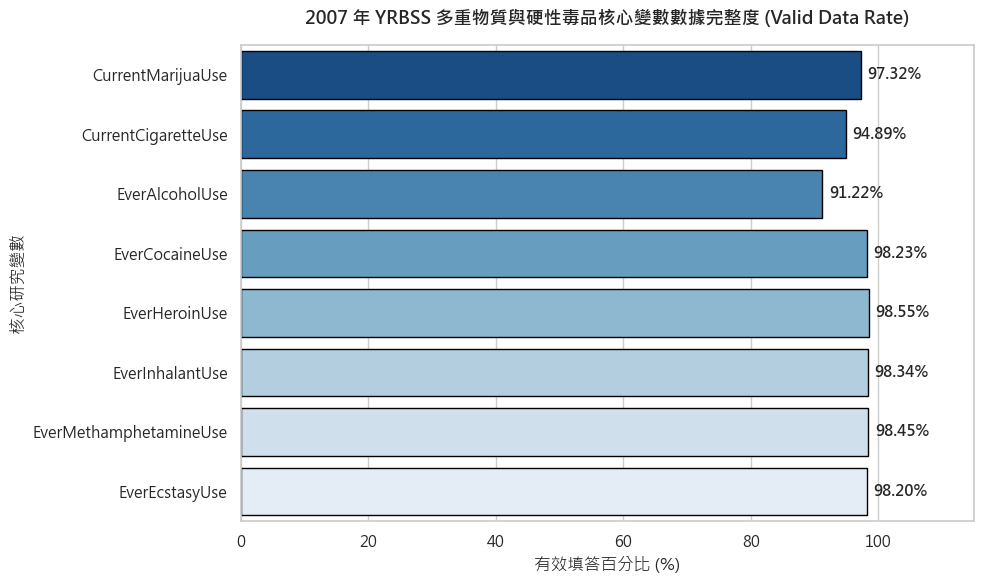

In [25]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("📊 正在繪製 8 大核心變數完整度視覺化圖表...")
target_columns = [
    'CurrentMarijuaUse',
    'CurrentCigaretteUse',
    'EverAlcoholUse',
    'EverCocaineUse', 
    'EverHeroinUse', 
    'EverInhalantUse', 
    'EverMethamphetamineUse', 
    'EverEcstasyUse'
]

# 1. 計算 8 個變數的「有效填答比例 (%)」
valid_rates = (df[target_columns].notna().sum() / len(df)) * 100
valid_df = valid_rates.to_frame(name='有效填答比例 (%)').reset_index()
valid_df.rename(columns={'index': '核心變數'}, inplace=True)

# 2. 使用環境初始化設定好的 seaborn 風格發動繪圖
plt.figure(figsize=(10, 6)) # 稍微加高高度 (從 5 改到 6)，讓 8 個變數長條排列更舒展、不擁擠
ax = sns.barplot(
    x='有效填答比例 (%)', 
    y='核心變數', 
    data=valid_df, 
    palette='Blues_r',
    edgecolor='black'
)

# 3. 在長條圖後方加上精準的數據標籤
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 1, 
        p.get_y() + p.get_height() / 2, 
        f'{width:.2f}%', 
        ha='left', 
        va='center', 
        fontsize=11, 
        fontweight='bold'
    )

# 4. 優化圖表外觀與學術標題
plt.title('2007 年 YRBSS 多重物質與硬性毒品核心變數數據完整度 (Valid Data Rate)', fontsize=13, fontweight='bold', pad=15)
plt.xlim(0, 115)  # 留出右側空間給標籤文字
plt.xlabel('有效填答百分比 (%)', fontsize=12)
plt.ylabel('核心研究變數', fontsize=12)
plt.tight_layout()

# 5. 將圖表存入專案指定輸出目錄
output_fig_path = '../outputs/figures/01_data_completeness.png'
os.makedirs(os.path.dirname(output_fig_path), exist_ok=True)
plt.savefig(output_fig_path, dpi=300)

print(f"🎉 8 大核心變數視覺化圖表已成功存檔至: {output_fig_path}")
plt.show()